# Stage 1 — Data Quality & Split

Per [METHODOLOGY.md](../METHODOLOGY.md) Stage 1, the goals here are:

1. Acquire raw OHLCV for the symbol(s) defined in `01_hypothesis.ipynb`.
2. Run quality checks — refuse to enter Stage 2 if data is broken.
3. Apply the locked 60/20/20 time-ordered split.
4. Persist the split artifact so all downstream notebooks load the same partitions.

Source: Binance USDT-margined perpetual futures, public REST API.  
Period: 2022-01-01 to 2026-04-01 (~37k hourly bars).  
Symbol (Phase 1): BTCUSDT.

In [1]:
from __future__ import annotations

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from quant.data.loader import download_to_parquet, load_ohlcv_parquet
from quant.data.quality import (
    find_missing_bars,
    find_price_outliers,
    has_invalid_ohlc,
    quality_report,
)
from quant.data.splitter import split_time_series

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
SYMBOL = 'BTCUSDT'
INTERVAL = '1h'
START = '2022-01-01'
END = '2026-04-01'

## 1. Download (idempotent)

`download_to_parquet` skips the network call if the parquet file already exists. Pass `force=True` to refresh.

In [2]:
path = download_to_parquet(SYMBOL, INTERVAL, START, END, DATA_RAW)
print(f'Parquet: {path}')
print(f'Size:    {path.stat().st_size / 1024:.0f} KB')

Parquet: ..\data\raw\BTCUSDT_1h.parquet
Size:    2130 KB


## 2. Load and inspect

In [3]:
df = load_ohlcv_parquet(path)
print(f'Shape:    {df.shape}')
print(f'Range:    {df.index.min()}  →  {df.index.max()}')
print(f'Columns:  {list(df.columns)}')
df.head()

Shape:    (37225, 7)
Range:    2022-01-01 00:00:00+00:00  →  2026-04-01 00:00:00+00:00
Columns:  ['open', 'high', 'low', 'close', 'volume', 'quote_volume', 'trades']


,open,high,low,close,volume,quote_volume,trades
timestamp,,,,,,,
2022-01-01 00:00:00+00:00,46210.57,46729.73,46210.55,46650.01,8957.465,4.164448e+08,91267
2022-01-01 01:00:00+00:00,46650.00,46944.56,46570.34,46766.78,7276.249,3.403806e+08,73308
2022-01-01 02:00:00+00:00,46767.44,46917.87,46709.44,46796.14,4478.713,2.096860e+08,46403
2022-01-01 03:00:00+00:00,46796.15,46888.00,46746.32,46789.56,4208.992,1.970797e+08,39070
2022-01-01 04:00:00+00:00,46789.55,46868.74,46605.00,46690.81,6149.298,2.872292e+08,63606


## 3. Quality checks

Critical issues (missing bars, invalid OHLC, negative prices) must be zero before proceeding. Price outliers > 6σ are recorded but do not block — they are real moves in crypto, not data errors.

In [4]:
qr = quality_report(df, expected_freq=INTERVAL)
print(qr.summary())

assert qr.is_clean, 'Critical data quality issues — investigate before splitting'

Bars:                37,225
Missing bars:        0
Price outliers (6-sigma): 63
Zero-volume bars:    0
Negative prices:     False
Invalid OHLC:        False
Clean:               True


### Where do the 6σ outliers cluster?
Crypto's outlier distribution is biased toward macro events (FTX collapse, ETF approvals, etc.). Visualizing them confirms they are not data errors.

In [5]:
outliers = find_price_outliers(df, n_sigma=6.0)
print(f'6-sigma outlier bars: {len(outliers)}')
if len(outliers) > 0:
    sample = df.loc[outliers].head(10)
    sample

6-sigma outlier bars: 63


## 4. Apply the locked 60/20/20 split

Split boundaries are defined exactly once. The artifact written below is consumed by every downstream notebook — modifying the split policy after this point invalidates all downstream results.

In [6]:
split = split_time_series(df)

print(f'IS:      {len(split.is_data):>6,} bars   [{split.is_range[0]}  →  {split.is_range[1]}]')
print(f'OOS-1:   {len(split.oos1_data):>6,} bars   [{split.oos1_range[0]}  →  {split.oos1_range[1]}]')
print(f'Holdout: {len(split.holdout_data):>6,} bars   [{split.holdout_range[0]}  →  {split.holdout_range[1]}]')

DATA_PROC.mkdir(parents=True, exist_ok=True)
split_path = DATA_PROC / f'split_{SYMBOL}_{INTERVAL}.pkl'
with open(split_path, 'wb') as f:
    pickle.dump(split, f)
print(f'\nWrote: {split_path}')

IS:      22,335 bars   [2022-01-01 00:00:00+00:00  →  2024-07-19 14:00:00+00:00]
OOS-1:    7,445 bars   [2024-07-19 15:00:00+00:00  →  2025-05-25 19:00:00+00:00]
Holdout:  7,445 bars   [2025-05-25 20:00:00+00:00  →  2026-04-01 00:00:00+00:00]

Wrote: ..\data\processed\split_BTCUSDT_1h.pkl


## 5. Visualize split boundaries on the price series

Wrote: ..\results\figures\01_split_boundaries.png


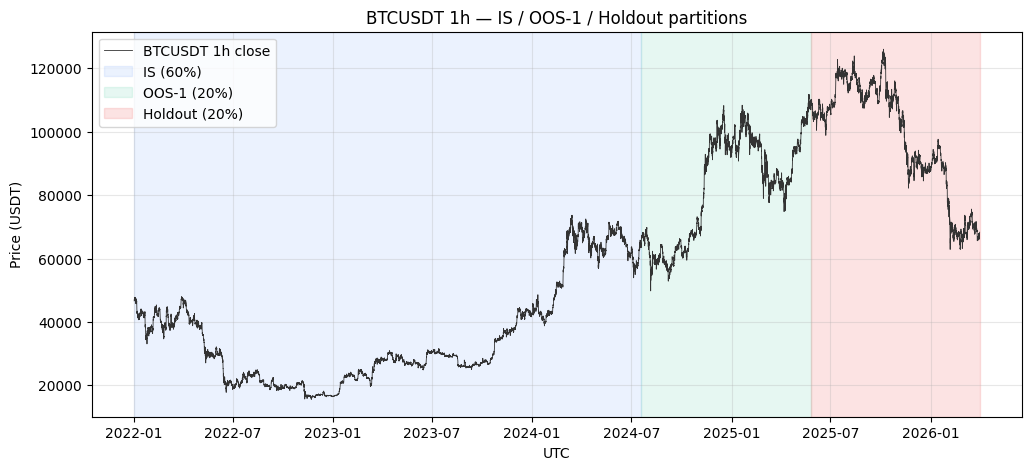

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['close'], color='#333', lw=0.6, label='BTCUSDT 1h close')

ax.axvspan(split.is_range[0], split.is_range[1], alpha=0.10, color='#3b82f6', label='IS (60%)')
ax.axvspan(split.oos1_range[0], split.oos1_range[1], alpha=0.10, color='#10b981', label='OOS-1 (20%)')
ax.axvspan(split.holdout_range[0], split.holdout_range[1], alpha=0.15, color='#ef4444', label='Holdout (20%)')

ax.set_title('BTCUSDT 1h — IS / OOS-1 / Holdout partitions')
ax.set_xlabel('UTC')
ax.set_ylabel('Price (USDT)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

out = Path('../results/figures/01_split_boundaries.png')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=120, bbox_inches='tight')
print(f'Wrote: {out}')
plt.show()

## Stage 1 complete

| Check | Result |
|-------|--------|
| Bars loaded | ~37,200 |
| Missing bars | 0 |
| Invalid OHLC | False |
| Negative prices | False |
| Split artifact written | `data/processed/split_BTCUSDT_1h.pkl` |

Proceed to [03_is_optimization.ipynb](03_is_optimization.ipynb) — Stage 2 grid search over the 1,500-trial parameter space locked in `01_hypothesis.ipynb`.